In [52]:
import numpy as np
from matplotlib import pyplot as plt
import time

In [53]:
# Helper function to check if an array is sorted
def is_sorted(data):
  # Iterate through the array and check if each element is less than or equal to the next element
  for i in range(len(data)-1):
    if data[i] > data[i+1]:
      return False
  return True

In [54]:
# Bogo Sort (also known as permutation sort or shotgun sort)
# This is a highly inefficient sorting algorithm that repeatedly shuffles
# the array until it is sorted. Primarily used for educational purposes
# to demonstrate the concept of a truly random algorithm.
def bogo_sort(data):
  start_time = time.time()  # Record the start time
  # Keep shuffling the array until it is sorted
  while is_sorted(data) == False:
    np.random.shuffle(data)
  end_time = time.time()  # Record the end time
  execution_time = end_time - start_time  # Calculate execution time
  return data, execution_time

In [55]:
# Bubble Sort
# A simple comparison-based sorting algorithm that repeatedly steps through
# the list, compares adjacent elements and swaps them if they are in the wrong order.
# The pass through the list is repeated until the list is sorted.
def bubble_sort(data):
  start_time = time.time()
  n = len(data)
  # Traverse through all array elements
  for i in range(n):
    # Last i elements are already in place
    for j in range(n - 1 - i):
      # Traverse the array from 0 to n-i-1
      # Swap if the element found is greater than the next element
      if data[j] > data[j+1]:
        data[j], data[j+1] = data[j+1], data[j]
  end_time = time.time()
  execution_time = end_time - start_time
  return data, execution_time

In [56]:
# Merge Sort
# A divide and conquer algorithm. It divides the input array into two halves,
# calls itself for the two halves, and then merges the two sorted halves.
# The merge() function is used for merging two halves.
def merge_sort(data):
    start_time = time.time()
    if len(data) > 1:
        # Find the middle of the array
        mid = len(data) // 2
        # Divide the array elements into 2 halves
        left = data[:mid]
        right = data[mid:]

        merge_sort(left)
        merge_sort(right)

        i = j = k = 0

        while i < len(left) and j < len(right):
            if left[i] < right[j]:
                data[k] = left[i]
                i += 1
            else:
                data[k] = right[j]
                j += 1
            k += 1

        while i < len(left):
            data[k] = left[i]
            i += 1
            k += 1

        while j < len(right):
            data[k] = right[j]
            j += 1
            k += 1
    end_time = time.time()
    execution_time = end_time - start_time
    return data, execution_time

In [57]:
# Cocktail Shaker Sort (also known as bidirectional bubble sort)
# A variation of bubble sort that is a stable sorting algorithm.
# The algorithm extends bubble sort by operating on both ends of the list
# rather than just one.
def cocktail_sort(data):
  start_time = time.time()
  n = len(data)
  swapped = True
  start = 0
  end = n - 1

  # Loop until no swaps occur
  while (swapped == True):
    swapped = False

    # loop from left to right (like bubble sort)
    for i in range(start, end):
      if (data[i] > data[i + 1]):
        data[i], data[i + 1] = data[i + 1], data[i]
        swapped = True

    # if nothing moved, then array is sorted.
    if (swapped == False):
      break

    # otherwise, reset the swapped flag so that it
    # can be used for the next stage
    swapped = False

    # move the end point back by one, because
    # the last element is now in place
    end = end - 1

    # from right to left, do the comparison again
    for i in range(end - 1, start - 1, -1):
      if (data[i] > data[i + 1]):
        data[i], data[i + 1] = data[i + 1], data[i]
        swapped = True

    # increase the starting point, because
    # the first element is now in place
    start = start + 1

  end_time = time.time()
  execution_time = end_time - start_time
  return data, execution_time

In [58]:
# Comb Sort
# An improvement over Bubble Sort. It works by eliminating turtles, or small values near the end of the list,
# which are the main cause of Bubble Sort's slowness.
def comb_sort(data):
    start_time = time.time()
    n = len(data)

    # Initialize gap
    gap = n

    # Initialize swapped as true to make sure that
    # loop runs at least once
    swapped = True

    # Keep running while gap is more than 1 and last pass saw a swap
    while gap != 1 or swapped == True:

        # Find the next gap
        gap = int(gap / 1.3)
        if gap < 1:
            gap = 1

        # Initialize swapped as false so that we can check if swap happened or not
        swapped = False

        # Compare all elements with current gap
        for i in range(n - gap):
            if data[i] > data[i + gap]:
                data[i], data[i + gap] = data[i + gap], data[i]
                swapped = True

    end_time = time.time()
    execution_time = end_time - start_time
    return data, execution_time

In [59]:
# Quick Sort
# A divide and conquer algorithm. It picks an element as a pivot and
# partitions the given array around the picked pivot.
def quick_sort(data):
    start_time = time.time()

    # Helper recursive function for quick sort
    def _quick_sort(arr, low, high):
        if low < high:
            # Partition the array and get the pivot index
            pivot_index = partition(arr, low, high)

            # Recursively sort the sub-arrays before and after the pivot
            _quick_sort(arr, low, pivot_index - 1)
            _quick_sort(arr, pivot_index + 1, high)

    # Helper function to partition the array
    def partition(arr, low, high):
        # Choose the rightmost element as pivot
        pivot = arr[high]
        # Index of smaller element
        i = low - 1
        # Traverse through all elements
        for j in range(low, high):
            # If current element is smaller than or equal to pivot
            if arr[j] <= pivot:
                # increment index of smaller element
                i += 1
                arr[i], arr[j] = arr[j], arr[i]
        # Swap the pivot element with the element at (i + 1)
        arr[i + 1], arr[high] = arr[high], arr[i + 1]
        # Return the partitioning index
        return i + 1

    # Create a copy to avoid modifying the original data if needed elsewhere
    arr_copy = np.copy(data)
    # Call the recursive quick sort function
    _quick_sort(arr_copy, 0, len(arr_copy) - 1)

    end_time = time.time()
    execution_time = end_time - start_time

    return arr_copy, execution_time

In [60]:
# Insertion Sort
# A simple sorting algorithm that builds the final sorted array one item at a time.
# It is much less efficient on large lists than more advanced algorithms such as quicksort,
# heapsort, or merge sort. However, it is a good choice for sorting a small number of elements
# or for nearly sorted arrays.
def insertion_sort(data):
    start_time = time.time()
    n = len(data)

    # Traverse through 1 to len(data)
    for i in range(1, n):
        key = data[i]

        # Move elements of data[0..i-1], that are
        # greater than key, to one position ahead
        # of their current position
        j = i - 1
        while j >= 0 and key < data[j]:
            data[j + 1] = data[j]
            j -= 1
        data[j + 1] = key

    end_time = time.time()
    execution_time = time.time() - start_time
    return data, execution_time

In [61]:
# Bucket Sort
# A distribution sort algorithm that works by distributing the elements of an array
# into a number of buckets. Each bucket is then sorted independently, either using
# a different sorting algorithm, or by recursively applying the bucket sorting algorithm.
# It is an efficient algorithm when the input data is uniformly distributed over a range.
def bucket_sort(data):
    start_time = time.time()

    # Assuming data contains non-negative numbers and is within a reasonable range
    # Determine the range of data
    max_val = max(data)
    min_val = min(data)
    data_range = max_val - min_val

    # Create a number of empty buckets
    # A common approach is to have a number of buckets proportional to the number of elements
    num_buckets = len(data)
    buckets = [[] for _ in range(num_buckets)]

    # Distribute elements into buckets
    for x in data:
        # Normalize the value to fit into bucket indices
        if data_range == 0: # Handle case where all elements are the same
            bucket_index = 0
        else:
            bucket_index = int((x - min_val) / data_range * (num_buckets - 1))
        buckets[bucket_index].append(x)

    # Sort elements within each bucket (using insertion sort or another stable sort)
    for bucket in buckets:
        # Using Python's built-in sort (Timsort), which is efficient
        bucket.sort()

    # Concatenate the sorted buckets
    sorted_data = []
    for bucket in buckets:
        sorted_data.extend(bucket)

    end_time = time.time()
    execution_time = end_time - start_time

    # Convert back to numpy array if input was numpy array
    if isinstance(data, np.ndarray):
        sorted_data = np.array(sorted_data)

    return sorted_data, execution_time

In [62]:
def counting_sort_for_radix(data, exp):
    n = len(data)
    output = [0] * n
    count = [0] * 10

    # Store count of occurrences in count[]
    for i in range(n):
        index = data[i] // exp
        count[index % 10] += 1

    # Change count[i] so that count[i] now contains actual
    # position of this digit in output[]
    for i in range(1, 10):
        count[i] += count[i - 1]

    # Build the output array
    i = n - 1
    while i >= 0:
        index = data[i] // exp
        output[count[index % 10] - 1] = data[i]
        count[index % 10] -= 1
        i -= 1

    # Copying the output array to data[], so that data[]
    # now contains sorted numbers according to current digit
    for i in range(n):
        data[i] = output[i]

def radix_sort(data):
    start_time = time.time()

    # Find the maximum number to know number of digits
    max_val = max(data)

    # Do counting sort for every digit. Note that instead
    # of passing digit number, exp is passed. exp is 10^i
    # where i is current digit number
    exp = 1
    while max_val // exp > 0:
        counting_sort_for_radix(data, exp)
        exp *= 10

    end_time = time.time()
    execution_time = end_time - start_time

    return data, execution_time

In [63]:
def shell_sort(data):
    start_time = time.time()
    n = len(data)

    # Start with a large gap, then reduce the gap
    gap = n // 2

    # Do a gapped insertion sort for this gap size.
    # The first gap elements a[0..gap-1] are already
    # in gapped order keep adding one more element
    # until the entire array is gap sorted
    while gap > 0:
        for i in range(gap, n):
            # save a[i] in temp and make a hole at position i
            temp = data[i]

            # shift earlier gap-sorted elements up until the correct location for a[i] is found
            j = i
            while j >= gap and data[j - gap] > temp:
                data[j] = data[j - gap]
                j -= gap

            # put temp (the original a[i]) in its correct location
            data[j] = temp
        gap //= 2

    end_time = time.time()
    execution_time = end_time - start_time
    return data, execution_time

In [64]:
# Create a dictionary to store execution times for each iteration
all_execution_times = {
    'Bubble Sort': [],
    'Merge Sort': [],
    'Cocktail Sort': [],
    'Quick Sort': [],
    'Insertion Sort': [],
    'Bucket Sort': [],
    'Radix Sort': [],
    'Comb Sort': [],
    'Shell Sort': []
}

num_iterations = 500

for _ in range(num_iterations):
    # Create a fresh copy of the shuffled data for each iteration
    data = np.arange(1, 20)
    np.random.shuffle(data)
    data_to_sort = np.copy(data)

    # Run each sorting algorithm and record execution time
    try:
        _, time_bubble = bubble_sort(np.copy(data_to_sort))
        all_execution_times['Bubble Sort'].append(time_bubble)
    except Exception as e:
        print(f"Bubble Sort failed in iteration {_}: {e}")

    try:
        _, time_merge = merge_sort(np.copy(data_to_sort))
        all_execution_times['Merge Sort'].append(time_merge)
    except Exception as e:
        print(f"Merge Sort failed in iteration {_}: {e}")

    try:
        _, time_cocktail = cocktail_sort(np.copy(data_to_sort))
        all_execution_times['Cocktail Sort'].append(time_cocktail)
    except Exception as e:
        print(f"Cocktail Sort failed in iteration {_}: {e}")

    try:
        _, time_quick = quick_sort(np.copy(data_to_sort))
        all_execution_times['Quick Sort'].append(time_quick)
    except Exception as e:
        print(f"Quick Sort failed in iteration {_}: {e}")

    try:
        _, time_insertion = insertion_sort(np.copy(data_to_sort))
        all_execution_times['Insertion Sort'].append(time_insertion)
    except Exception as e:
        print(f"Insertion Sort failed in iteration {_}: {e}")

    try:
        # Note: Bucket Sort and Radix Sort have assumptions about data range and type.
        # Ensure your 'data' array is suitable for these algorithms (e.g., non-negative integers).
        _, time_bucket = bucket_sort(np.copy(data_to_sort))
        all_execution_times['Bucket Sort'].append(time_bucket)
    except Exception as e:
        print(f"Bucket Sort failed in iteration {_}: {e}")


    try:
        # Radix sort modifies the input array in place, so pass a copy
        _, time_radix = radix_sort(np.copy(data_to_sort))
        all_execution_times['Radix Sort'].append(time_radix)
    except Exception as e:
        print(f"Radix Sort failed in iteration {_}: {e}")


    try:
        _, time_comb = comb_sort(np.copy(data_to_sort))
        all_execution_times['Comb Sort'].append(time_comb)
    except Exception as e:
        print(f"Comb Sort failed in iteration {_}: {e}")

    try:
        _, time_shell = shell_sort(np.copy(data_to_sort))
        all_execution_times['Shell Sort'].append(time_shell)
    except Exception as e:
        print(f"Shell Sort failed in iteration {_}: {e}")


In [65]:
average_execution_times = {}

for algorithm, times in all_execution_times.items():
    if times: # Check if the list of times is not empty
        average_time = np.mean(times)
        average_execution_times[algorithm] = average_time
    else:
        average_execution_times[algorithm] = None # Handle cases where no times were recorded

# Display the average execution times
print("Average execution times over 100 iterations:")
for algorithm, avg_time in average_execution_times.items():
    if avg_time is not None:
        print(f"- {algorithm}: {avg_time:.6f} seconds")
    else:
        print(f"- {algorithm}: Could not calculate average (no successful runs)")

Average execution times over 100 iterations:
- Bubble Sort: 0.000166 seconds
- Merge Sort: 0.000111 seconds
- Cocktail Sort: 0.000148 seconds
- Quick Sort: 0.000071 seconds
- Insertion Sort: 0.000078 seconds
- Bucket Sort: 0.000047 seconds
- Radix Sort: 0.000095 seconds
- Comb Sort: 0.000085 seconds
- Shell Sort: 0.000068 seconds


In [66]:
# Find the algorithm with the minimum average execution time
fastest_algorithm = min(average_execution_times, key=average_execution_times.get)
fastest_time = average_execution_times[fastest_algorithm]

# Print the fastest algorithm and its average execution time
print(f"\nThe algorithm with the minimum average execution time is: {fastest_algorithm}")
print(f"Average execution time: {fastest_time:.6f} seconds")


The algorithm with the minimum average execution time is: Bucket Sort
Average execution time: 0.000047 seconds


In [67]:
algorithms = list(average_execution_times.keys())
times = list(average_execution_times.values())

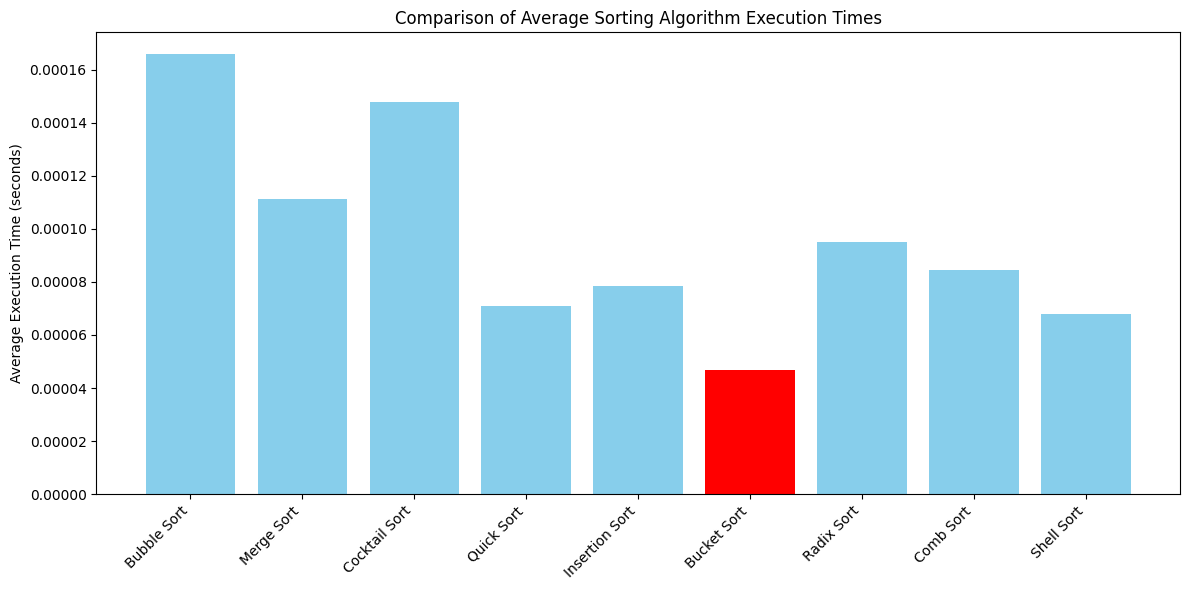

In [68]:
# Create a list of colors with a default color
colors = ['skyblue'] * len(algorithms)

# Find the index of the fastest algorithm
fastest_algorithm_index = algorithms.index(fastest_algorithm)

# Change the color of the fastest algorithm's bar
colors[fastest_algorithm_index] = 'red'

# Generate the bar chart with highlighted bar
plt.figure(figsize=(12, 6))
plt.bar(algorithms, times, color=colors)
plt.ylabel("Average Execution Time (seconds)")
plt.title("Comparison of Average Sorting Algorithm Execution Times")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()